# Восстановление золота из руды

# Gold Recovery from Ore


Подготовьте прототип модели машинного обучения для «Цифры». Компания разрабатывает решения для эффективной работы промышленных предприятий.

Модель должна предсказать коэффициент восстановления золота из золотосодержащей руды. Используйте данные с параметрами добычи и очистки.

Модель поможет оптимизировать производство, чтобы не запускать предприятие с убыточными характеристиками.

Вам нужно:

1. Подготовить данные;
2. Провести исследовательский анализ данных;
3. Построить и обучить модель.

Чтобы выполнить проект, обращайтесь к библиотекам *pandas*, *matplotlib* и *sklearn.* Вам поможет их документация.

---

Prepare a prototype of a machine learning model for **Tsifra**, a company that develops solutions for improving the efficiency of industrial enterprises.

The model must predict the **gold recovery rate** from gold-bearing ore using data on extraction and purification parameters.

The model will help optimize production and prevent launching operations with unprofitable characteristics.

Your task is to:

1. Prepare the data;
2. Conduct exploratory data analysis;
3. Build and train a model.

To complete the project, use the *pandas*, *matplotlib*, and *sklearn* libraries. Their documentation will be helpful.

#### Цель проекта:
- Построить модель для предсказания коэффициента восстановления золота из золотосодержащей руды. 

#### Данные:
- В распоряжение даны сырые данные стадий процессов обработки золотой руды: их просто выгрузили из хранилища. 

#### Ход исследования:
- Загрузка и подготовка данных:
  - Импортируем библиотеки и модули, необходимые для исследования.
  - Читаем файлы и сохраняем их в переменные.
  - Оцениваем содержимое датасетов и описываем его.
  - Проверим, правильно ли рассчитана эффективность обогащения для признака `rougher.output.recovery`. Вычислим её на обучающей выборке.
  - Проанализируем признаки, недоступные в тестовой выборке. Определим, что это за параметры и к какому типу они относятся.
  - Обработаем данные.
- Анализ данных:
  - Оценим изменение концентрации металлов (Au, Ag, Pb) на различных этапах: в сырье, в черновом концентрате, в концентрате после первой очистки и в финальном концентрате. Оценим особенности распределений. Сформулируем выводы.
  - Сравним распределения размеров гранул исходного сырья на обучающей и тестовой выборках.
  - Исследуем суммарную концентрацию металлов на разных стадиях: в сырье, в черновом концентрате, в концентрате после первой очистки и в финальном концентрате.
- Построение модели:
  - Напишем функцию для вычисления итоговой sMAPE.
  - Обучим разные модели и оценим их качество с помощью кросс-валидации. Выберем лучшую модель и опишем результаты.
  - Проверим лучшую модель на тестовой выборке.
- Общий вывод.

---

#### Project Objective:
- To build a model for predicting the recovery rate of gold from gold-bearing ore.

#### Data:
- The study is based on raw data from different stages of gold ore processing, directly exported from the storage system.

#### Research Plan:
- Data loading and preparation:
  - Import the libraries and modules required for the analysis.
  - Read the files and store them in variables.
  - Examine and describe the contents of the datasets.
  - Check whether the enrichment efficiency for the `rougher.output.recovery` feature was calculated correctly by recomputing it on the training set.
  - Analyze the features unavailable in the test dataset, determine what these parameters represent, and identify their type.
  - Preprocess the data.
- Data analysis:
  - Evaluate how the concentration of metals (Au, Ag, Pb) changes at different stages: in the raw feed, in the rough concentrate, in the concentrate after the first purification stage, and in the final concentrate. Analyze the distribution characteristics and formulate conclusions.
  - Compare the distributions of feed particle sizes in the training and test datasets.
  - Investigate the total concentration of metals at different stages: in the raw feed, rough concentrate, concentrate after the first purification stage, and final concentrate.
- Model building:
  - Create a function for calculating the final sMAPE metric.
  - Train different models and evaluate their performance using cross-validation. Select the best model and summarize the results.
  - Test the best model on the test set.
- Overall conclusion.

## Этап 1. Подготовка данных.

### 1.1 Импортируем библиотеки и модули:

In [1]:
#Собираем все импорты в одном месте
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor 
from sklearn.metrics import make_scorer
from sklearn.model_selection import train_test_split

### 1.2 Прочитаем файлы и сохраним их в переменные:

In [2]:
#локально
try:
    df_gold_train = pd.read_csv('/Users/danielschollenberg/Desktop/gold_industry_train.csv')
    df_gold_test = pd.read_csv('/Users/danielschollenberg/Desktop/gold_industry_test.csv')
    df_gold_full = pd.read_csv('/Users/danielschollenberg/Desktop/gold_industry_full.csv')
#с сервера
except:
    df_gold_train = pd.read_csv('https://code.s3.yandex.net/datasets/gold_industry_train.csv')
    df_gold_test = pd.read_csv('https://code.s3.yandex.net/datasets/gold_industry_test.csv')
    df_gold_full = pd.read_csv('https://code.s3.yandex.net/datasets/gold_industry_full.csv')

### 1.3 Изучим и опишем содержимое файлов:

#### 1.3.1 Для датасета обучающая выборка:

In [3]:
#Распечатаем информацию датасета обучающая выборка и его первые 4 строки
print(df_gold_train.info())
df_gold_train.head(4)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14579 entries, 0 to 14578
Data columns (total 87 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   date                                                14579 non-null  object 
 1   rougher.input.feed_au                               14579 non-null  float64
 2   rougher.input.feed_ag                               14579 non-null  float64
 3   rougher.input.feed_pb                               14507 non-null  float64
 4   rougher.input.feed_sol                              14502 non-null  float64
 5   rougher.input.feed_rate                             14572 non-null  float64
 6   rougher.input.feed_size                             14478 non-null  float64
 7   rougher.input.floatbank10_sulfate                   14548 non-null  float64
 8   rougher.input.floatbank10_xanthate                  14572 non-null  float64


,date,rougher.input.feed_au,rougher.input.feed_ag,rougher.input.feed_pb,rougher.input.feed_sol,rougher.input.feed_rate,rougher.input.feed_size,rougher.input.floatbank10_sulfate,rougher.input.floatbank10_xanthate,rougher.state.floatbank10_a_air,...,secondary_cleaner.output.tail_sol,final.output.concentrate_au,final.output.concentrate_ag,final.output.concentrate_pb,final.output.concentrate_sol,final.output.recovery,final.output.tail_au,final.output.tail_ag,final.output.tail_pb,final.output.tail_sol
0,2016-01-15 00:00:00,6.486150,6.100378,2.284912,36.808594,523.546326,55.486599,11.986616,6.007990,999.706909,...,8.764648,42.192020,6.055403,9.889648,5.507324,70.541216,2.143149,10.411962,0.895447,16.904297
1,2016-01-15 01:00:00,6.478583,6.161113,2.266033,35.753385,525.290581,57.278666,11.971193,6.005766,1000.286398,...,9.001494,42.701629,6.029369,9.968944,5.257781,69.266198,2.224930,10.462676,0.927452,16.634514
2,2016-01-15 02:00:00,6.362222,6.116455,2.159622,35.971630,530.026610,57.510649,11.920603,6.197377,999.719565,...,8.842896,42.657501,6.055926,10.213995,5.383759,68.116445,2.257889,10.507046,0.953716,16.208849
3,2016-01-15 03:00:00,6.118189,6.043309,2.037807,36.862241,542.590390,57.792734,11.630094,6.203177,999.814770,...,9.122857,42.689819,6.047977,9.977019,4.858634,68.347543,2.146849,10.422762,0.883763,16.532835


##### Вывод:
- Датасет имеет 14579 объектов(строк) и 86 признаков(столбцов) cледующего содержания:
  - Дата (date): Дата соответствующего технологического процесса. Всего 14579 записей.
  - rougher.input.feed_au: Количество золота в исходной смеси, подаваемой на этап флотации.
  - rougher.input.feed_ag: Количество серебра в исходной смеси, подаваемой на этап флотации.
  - rougher.input.feed_pb: Количество свинца в исходной смеси, подаваемой на этап флотации.
  - rougher.input.feed_sol: Количество растворенных веществ в исходной смеси, подаваемой на этап флотации.
  - rougher.input.feed_rate: Скорость подачи исходной смеси на этап флотации.
  - rougher.input.feed_size: Размер гранул исходной смеси, подаваемой на этап флотации.
  - rougher.input.floatbank10_sulfate: Количество сульфата, добавляемого на этапе флотации в установке floatbank10.
  - rougher.input.floatbank10_xanthate: Количество ксантогената, добавляемого на этапе флотации в установке floatbank10.
  - rougher.state.floatbank10_a_air: Объем воздуха, используемый на этапе флотации в установке floatbank10.
  - rougher.state.floatbank10_a_level: Уровень жидкости на этапе флотации в установке floatbank10.
  - rougher.state.floatbank10_b_air: Объем воздуха, используемый на этапе флотации в установке floatbank10.
  - rougher.state.floatbank10_b_level: Уровень жидкости на этапе флотации в установке floatbank10.
  - rougher.state.floatbank10_c_air: Объем воздуха, используемый на этапе флотации в установке floatbank10.
  - rougher.state.floatbank10_c_level: Уровень жидкости на этапе флотации в установке floatbank10.
  - rougher.state.floatbank10_d_air: Объем воздуха, используемый на этапе флотации в установке floatbank10.
  - rougher.state.floatbank10_d_level: Уровень жидкости на этапе флотации в установке floatbank10.
  - rougher.state.floatbank10_e_air: Объем воздуха, используемый на этапе флотации в установке floatbank10.
  - rougher.state.floatbank10_e_level: Уровень жидкости на этапе флотации в установке floatbank10.
  - rougher.state.floatbank10_f_air: Объем воздуха, используемый на этапе флотации в установке floatbank10.
  - rougher.state.floatbank10_f_level: Уровень жидкости на этапе флотации в установке floatbank10.
  - rougher.input.floatbank11_sulfate: Количество сульфата, добавляемого на этапе флотации в установке floatbank11.
  - rougher.input.floatbank11_xanthate: Количество ксантогената, добавляемого на этапе флотации в установке floatbank11.
  - rougher.calculation.sulfate_to_au_concentrate: Расчетное соотношение сульфата к концентрату золота.
  - rougher.calculation.floatbank10_sulfate_to_au_feed: Расчетное соотношение сульфата к подаваемой на флотацию смеси золотосодержащей руды в установке floatbank10.
  - rougher.calculation.floatbank11_sulfate_to_au_feed: Расчетное соотношение сульфата к подаваемой на флотацию смеси золотосодержащей руды в установке floatbank11.
  - rougher.calculation.au_pb_ratio: Расчетное отношение золота к свинцу.
  - rougher.output.concentrate_au: Концентрация золота в черновом концентрате после этапа флотации.
  - rougher.output.concentrate_ag: Концентрация серебра в черновом концентрате после этапа флотации.
  - rougher.output.concentrate_pb: Концентрация свинца в черновом концентрате после этапа флотации.
  - rougher.output.concentrate_sol: Концентрация растворенных веществ в черновом концентрате после этапа флотации.
  - rougher.output.recovery: Эффективность обогащения золота после этапа флотации.
  - rougher.output.tail_au: Количество золота в отвальных хвостах после этапа флотации.
  - rougher.output.tail_ag: Количество серебра в отвальных хвостах после этапа флотации.
  - rougher.output.tail_pb: Количество свинца в отвальных хвостах после этапа флотации.
  - rougher.output.tail_sol: Количество растворенных веществ в отвальных хвостах после этапа флотации.
  - primary_cleaner.input.sulfate: Количество сульфата, добавляемого на этапе первичной очистки.
  - primary_cleaner.input.depressant: Количество депрессанта, добавляемого на этапе первичной очистки.
  - primary_cleaner.input.feed_size: Размер гранул подаваемого на первичную очистку сырья.
  - primary_cleaner.input.xanthate: Количество ксантогената, добавляемого на этапе первичной очистки.
  - primary_cleaner.state.floatbank8_a_air: Объем воздуха, используемый на этапе первичной очистки в установке floatbank8_a.
  - primary_cleaner.state.floatbank8_a_level: Уровень жидкости на этапе первичной очистки в установке floatbank8_a.
  - primary_cleaner.state.floatbank8_b_air: Объем воздуха, используемый на этапе первичной очистки в установке floatbank8_b.
  - primary_cleaner.state.floatbank8_b_level: Уровень жидкости на этапе первичной очистки в установке floatbank8_b.
  - primary_cleaner.state.floatbank8_c_air: Объем воздуха, используемый на этапе первичной очистки в установке floatbank8_c.
  - primary_cleaner.state.floatbank8_c_level: Уровень жидкости на этапе первичной очистки в установке floatbank8_c.
  - primary_cleaner.state.floatbank8_d_air: Объем воздуха, используемый на этапе первичной очистки в установке floatbank8_d.
  - primary_cleaner.state.floatbank8_d_level: Уровень жидкости на этапе первичной очистки в установке floatbank8_d.
  - primary_cleaner.output.concentrate_au: Концентрация золота в концентрате после этапа первичной очистки.
  - primary_cleaner.output.concentrate_ag: Концентрация серебра в концентрате после этапа первичной очистки.
  - primary_cleaner.output.concentrate_pb: Концентрация свинца в концентрате после этапа первичной очистки.
  - primary_cleaner.output.concentrate_sol: Концентрация растворенных веществ в концентрате после этапа первичной очистки.
  - primary_cleaner.output.tail_au: Количество золота в отвальных хвостах после этапа первичной очистки.
  - primary_cleaner.output.tail_ag: Количество серебра в отвальных хвостах после этапа первичной очистки.
  - primary_cleaner.output.tail_pb: Количество свинца в отвальных хвостах после этапа первичной очистки.
  - primary_cleaner.output.tail_sol: Количество растворенных веществ в отвальных хвостах после этапа первичной очистки.
  - secondary_cleaner.state.floatbank2_a_air: Объем воздуха, используемый на этапе вторичной очистки в установке floatbank2_a.
  - secondary_cleaner.state.floatbank2_a_level: Уровень жидкости на этапе вторичной очистки в установке floatbank2_a.
  - secondary_cleaner.state.floatbank2_b_air: Объем воздуха, используемый на этапе вторичной очистки в установке floatbank2_b.
  - secondary_cleaner.state.floatbank2_b_level: Уровень жидкости на этапе вторичной очистки в установке floatbank2_b.
  - secondary_cleaner.state.floatbank3_a_air: Объем воздуха, используемый на этапе вторичной очистки в установке floatbank3_a.
  - secondary_cleaner.state.floatbank3_a_level: Уровень жидкости на этапе вторичной очистки в установке floatbank3_a.
  - secondary_cleaner.state.floatbank3_b_air: Объем воздуха, используемый на этапе вторичной очистки в установке floatbank3_b.
  - secondary_cleaner.state.floatbank3_b_level: Уровень жидкости на этапе вторичной очистки в установке floatbank3_b.
  - secondary_cleaner.state.floatbank4_a_air: Объем воздуха, используемый на этапе вторичной очистки в установке floatbank4_a.
  - secondary_cleaner.state.floatbank4_a_level: Уровень жидкости на этапе вторичной очистки в установке floatbank4_a.
  - secondary_cleaner.state.floatbank4_b_air: Объем воздуха, используемый на этапе вторичной очистки в установке floatbank4_b.
  - secondary_cleaner.state.floatbank4_b_level: Уровень жидкости на этапе вторичной очистки в установке floatbank4_b.
  - secondary_cleaner.state.floatbank5_a_air: Объем воздуха, используемый на этапе вторичной очистки в установке floatbank5_a.
  - secondary_cleaner.state.floatbank5_a_level: Уровень жидкости на этапе вторичной очистки в установке floatbank5_a.
  - secondary_cleaner.state.floatbank5_b_air: Объем воздуха, используемый на этапе вторичной очистки в установке floatbank5_b.
  - secondary_cleaner.state.floatbank5_b_level: Уровень жидкости на этапе вторичной очистки в установке floatbank5_b.
  - secondary_cleaner.state.floatbank6_a_air: Объем воздуха, используемый на этапе вторичной очистки в установке floatbank6_a.
  - secondary_cleaner.state.floatbank6_a_level: Уровень жидкости на этапе вторичной очистки в установке floatbank6_a.
  - secondary_cleaner.output.tail_au: Количество золота в отвальных хвостах после этапа вторичной очистки.
  - secondary_cleaner.output.tail_ag: Количество серебра в отвальных хвостах после этапа вторичной очистки.
  - secondary_cleaner.output.tail_pb: Количество свинца в отвальных хвостах после этапа вторичной очистки.
  - secondary_cleaner.output.tail_sol: Количество растворенных веществ в отвальных хвостах после этапа вторичной очистки.
  - final.output.concentrate_au: Концентрация золота в финальном концентрате после всех этапов обработки.
  - final.output.concentrate_ag: Концентрация серебра в финальном концентрате после всех этапов обработки.
  - final.output.concentrate_pb: Концентрация свинца в финальном концентрате после всех этапов обработки.
  - final.output.concentrate_sol: Концентрация растворенных веществ в финальном концентрате после всех этапов обработки.
  - final.output.recovery: Эффективность обогащения золота в финальном концентрате.
  - final.output.tail_au: Количество золота в отвальных хвостах после всех этапов обработки.
  - final.output.tail_ag: Количество серебра в отвальных хвостах после всех этапов обработки.
  - final.output.tail_pb: Количество свинца в отвальных хвостах после всех этапов обработки.
  - final.output.tail_sol: Количество растворенных веществ в отвальных хвостах после всех этапов обработки.
- Для нас целевым признаком является столбец:
   - final.output.recovery: Эффективность обогащения золота в финальном концентрате.
- Он расчитывается по формуле: ((C*(F-T))/(F*(C-T)))*100%
   - где:
      - C — доля золота в концентрате после флотации/очистки; Столбец: rougher.output.concentrate_au;
      - F — доля золота в сырье/концентрате до флотации/очистки; Столбец: rougher.input.feed_au;
      - T — доля золота в отвальных хвостах после флотации/очистки. Столбец: rougher.output.tail_au;

#### 1.3.2 Для датасета тестовая выборка:

In [4]:
#Распечатаем информацию датасета тестовая выборка и его первые 4 строки
print(df_gold_test.info())
df_gold_test.head(4)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4860 entries, 0 to 4859
Data columns (total 53 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   date                                        4860 non-null   object 
 1   rougher.input.feed_au                       4860 non-null   float64
 2   rougher.input.feed_ag                       4860 non-null   float64
 3   rougher.input.feed_pb                       4832 non-null   float64
 4   rougher.input.feed_sol                      4838 non-null   float64
 5   rougher.input.feed_rate                     4856 non-null   float64
 6   rougher.input.feed_size                     4816 non-null   float64
 7   rougher.input.floatbank10_sulfate           4857 non-null   float64
 8   rougher.input.floatbank10_xanthate          4859 non-null   float64
 9   rougher.state.floatbank10_a_air             4859 non-null   float64
 10  rougher.stat

,date,rougher.input.feed_au,rougher.input.feed_ag,rougher.input.feed_pb,rougher.input.feed_sol,rougher.input.feed_rate,rougher.input.feed_size,rougher.input.floatbank10_sulfate,rougher.input.floatbank10_xanthate,rougher.state.floatbank10_a_air,...,secondary_cleaner.state.floatbank4_a_air,secondary_cleaner.state.floatbank4_a_level,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level
0,2017-12-09 14:59:59,4.365491,6.158718,3.875727,39.135119,555.820208,94.544358,6.146982,9.308612,1196.238112,...,23.018622,-500.492702,20.020205,-500.220296,17.963512,-499.939490,12.990306,-500.080993,19.990336,-499.191575
1,2017-12-09 15:59:59,4.362781,6.048130,3.902537,39.713906,544.731687,123.742430,6.210119,9.297709,1201.904177,...,23.024963,-501.153409,20.054122,-500.314711,17.979515,-499.272871,12.992404,-499.976268,20.013986,-500.625471
2,2017-12-09 16:59:59,5.081681,6.082745,4.564078,37.208683,558.155110,82.610855,7.363824,9.003562,1200.826926,...,22.993827,-501.559663,20.029144,-500.000662,18.012723,-500.024764,13.016445,-500.058432,19.973767,-501.394155
3,2017-12-09 17:59:59,5.145949,6.084374,4.768124,36.808874,539.713765,77.984784,6.927072,8.955597,1199.292489,...,23.032807,-501.287889,19.977466,-500.159903,17.980463,-500.504602,12.949071,-500.009937,20.010332,-508.337973


##### Вывод:
- Датасет имеет 4860 объектов(строк) и 53 признаков(столбцов).
- Признаков на 33 признака меньше, чем на обучающий выборке.

#### Для датасета с исходными данными:

In [5]:
#Распечатаем информацию датасета с исходными данными и его первые 4 строки
print(df_gold_full.info())
df_gold_full.head(4)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19439 entries, 0 to 19438
Data columns (total 87 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   date                                                19439 non-null  object 
 1   rougher.input.feed_au                               19439 non-null  float64
 2   rougher.input.feed_ag                               19439 non-null  float64
 3   rougher.input.feed_pb                               19339 non-null  float64
 4   rougher.input.feed_sol                              19340 non-null  float64
 5   rougher.input.feed_rate                             19428 non-null  float64
 6   rougher.input.feed_size                             19294 non-null  float64
 7   rougher.input.floatbank10_sulfate                   19405 non-null  float64
 8   rougher.input.floatbank10_xanthate                  19431 non-null  float64


,date,rougher.input.feed_au,rougher.input.feed_ag,rougher.input.feed_pb,rougher.input.feed_sol,rougher.input.feed_rate,rougher.input.feed_size,rougher.input.floatbank10_sulfate,rougher.input.floatbank10_xanthate,rougher.state.floatbank10_a_air,...,secondary_cleaner.output.tail_sol,final.output.concentrate_au,final.output.concentrate_ag,final.output.concentrate_pb,final.output.concentrate_sol,final.output.recovery,final.output.tail_au,final.output.tail_ag,final.output.tail_pb,final.output.tail_sol
0,2016-01-15 00:00:00,6.486150,6.100378,2.284912,36.808594,523.546326,55.486599,11.986616,6.007990,999.706909,...,8.764648,42.192020,6.055403,9.889648,5.507324,70.541216,2.143149,10.411962,0.895447,16.904297
1,2016-01-15 01:00:00,6.478583,6.161113,2.266033,35.753385,525.290581,57.278666,11.971193,6.005766,1000.286398,...,9.001494,42.701629,6.029369,9.968944,5.257781,69.266198,2.224930,10.462676,0.927452,16.634514
2,2016-01-15 02:00:00,6.362222,6.116455,2.159622,35.971630,530.026610,57.510649,11.920603,6.197377,999.719565,...,8.842896,42.657501,6.055926,10.213995,5.383759,68.116445,2.257889,10.507046,0.953716,16.208849
3,2016-01-15 03:00:00,6.118189,6.043309,2.037807,36.862241,542.590390,57.792734,11.630094,6.203177,999.814770,...,9.122857,42.689819,6.047977,9.977019,4.858634,68.347543,2.146849,10.422762,0.883763,16.532835


##### Вывод:

#### 1.3.4 Общий вывод:
- Датасет имеет 19439 объектов(строк) и 86 признаков(столбцов).
- По сути просто два совмешенных датасета вместе.

### 1.4 Проверим правильно ли рассчитана эффективность обогащения для признака rougher.output.recovery. Вычислим её на обучающей выборке.

#### 1.4.1 Напишем функцию для подсчета

In [6]:
#Напишем функцию для расчёт эффективности обогащения чернового концентрата
def recovery_rougher(data):
    #Определим переменные C,F,T
    C = data['rougher.output.concentrate_au']
    F = data['rougher.input.feed_au']
    T = data['rougher.output.tail_au']
    #Посчитаем по формуле эффективность и запишем результат в переменную
    recovery = (((C * (F - T)) / (F * (C - T))) * 100)
    #Вернем результат работы
    return recovery

#И сразу напишем такую-же функцию для финального концентрата
def recovery_final(data):
    #Определим переменные C,F,T
    C = data['final.output.concentrate_au']
    F = data['final.output.concentrate_au']
    T = data['final.output.tail_au']
    #Посчитаем по формуле эффективность и запишем результат в переменную
    recovery = (((C * (F - T)) / (F * (C - T))) * 100)
    #Вернем результат работы
    return recovery

#### 1.4.2 Посчитаем с помощью нашей функции эффективность обогащения для чернового концентрата. Сохраним результат в новый столбец датафрейма. Посчитаем MAE между нашими расчётами и значением признака в df. Опишем выводы.

In [7]:
#Запишем результат работы нашей функции в новый столбец
df_gold_train['rougher.output.recovery_func_result'] = df_gold_train.apply(recovery_rougher, axis=1)

In [8]:
#Вычисляем MAE между нашими расчетами и значением признака
mae = mean_absolute_error(df_gold_train['rougher.output.recovery'],
                          df_gold_train['rougher.output.recovery_func_result'])
#Выводим результат
print("MAE между нашими расчетами и значением признака:", mae)

MAE между нашими расчетами и значением признака: 9.862076326186705e-15


#### Выводы:
- MAE = 9.862076326186705e-15 = 9.862076326186705 * 10^(-15) = 0.000000000000009862076326186705
- Это очень маленькое число, близкое к нулю. Такое низкое значение MAE указывает на то, что наши расчеты практически идеально совпадают со значениями столбца rougher.output.recovery.
- В данном контексте это означает, что результат эффективность обогащения для чернового концентрата, записанный в столбце rougher.output.recovery. тестовой выборки расчитан правильно.

### 1.5 Проанализируем признаки, недоступные в тестовой выборке. Определим что это за параметры и к какому типу они относятся.

In [9]:
#Выведем на экране список столбцов, которые есть в тренировочной выборке, но отсутствуют в тестовой
display(list(set(df_gold_train.columns) - set(df_gold_test.columns)))

['primary_cleaner.output.concentrate_sol',
 'final.output.tail_au',
 'rougher.output.tail_sol',
 'primary_cleaner.output.tail_au',
 'secondary_cleaner.output.tail_sol',
 'final.output.concentrate_pb',
 'rougher.calculation.floatbank10_sulfate_to_au_feed',
 'primary_cleaner.output.tail_ag',
 'primary_cleaner.output.concentrate_ag',
 'rougher.output.tail_ag',
 'primary_cleaner.output.concentrate_pb',
 'primary_cleaner.output.tail_pb',
 'secondary_cleaner.output.tail_pb',
 'rougher.output.recovery_func_result',
 'final.output.concentrate_au',
 'rougher.output.recovery',
 'final.output.concentrate_ag',
 'rougher.calculation.floatbank11_sulfate_to_au_feed',
 'rougher.output.tail_pb',
 'secondary_cleaner.output.tail_ag',
 'rougher.output.concentrate_sol',
 'primary_cleaner.output.concentrate_au',
 'primary_cleaner.output.tail_sol',
 'rougher.calculation.sulfate_to_au_concentrate',
 'rougher.calculation.au_pb_ratio',
 'rougher.output.concentrate_au',
 'final.output.recovery',
 'rougher.output

##### Вывод:
##### Эти столбцы и что они означают:

- rougher.output.concentrate_pb: Доля свинца в концентрате после флотации.
- rougher.output.tail_pb: Доля свинца в отвальных хвостах после флотации.
- rougher.calculation.au_pb_ratio: Расчетное отношение золота к свинцу.
- rougher.output.recovery_func_result: Результат функции для расчета эффективности обогащения чернового концентрата.
- rougher.calculation.sulfate_to_au_concentrate: Расчетное соотношение сульфата к золоту в концентрате.
- rougher.output.concentrate_ag: Доля серебра в концентрате после флотации.
- rougher.output.tail_sol: Доля растворенного вещества в отвальных хвостах после флотации.
- final.output.concentrate_pb: Доля свинца в финальном концентрате.
- final.output.concentrate_au: Доля золота в финальном концентрате.
- rougher.output.concentrate_sol: Доля растворенного вещества в концентрате после флотации.
- primary_cleaner.output.tail_au: Доля золота в отвальных хвостах после первичной очистки.
- rougher.output.concentrate_au: Доля золота в концентрате после флотации.
- final.output.tail_pb: Доля свинца в отвальных хвостах после всех этапов обработки.
- rougher.calculation.floatbank11_sulfate_to_au_feed: Расчетное соотношение сульфата к золоту в подаче на флотацию.
- final.output.concentrate_sol: Доля растворенного вещества в финальном концентрате.
- secondary_cleaner.output.tail_pb: Доля свинца в отвальных хвостах после вторичной очистки.
- primary_cleaner.output.concentrate_pb: Доля свинца в концентрате после первичной очистки.
- rougher.output.tail_au: Доля золота в отвальных хвостах после флотации.
- primary_cleaner.output.concentrate_sol: Доля растворенного вещества в концентрате после первичной очистки.
- secondary_cleaner.output.tail_ag: Доля серебра в отвальных хвостах после вторичной очистки.
- primary_cleaner.output.tail_ag: Доля серебра в отвальных хвостах после первичной очистки.
- secondary_cleaner.output.tail_sol: Доля растворенного вещества в отвальных хвостах после вторичной очистки.
- primary_cleaner.output.tail_sol: Доля растворенного вещества в отвальных хвостах после первичной очистки.
- final.output.tail_au: Доля золота в отвальных хвостах после всех этапов обработки.
- rougher.output.tail_ag: Доля серебра в отвальных хвостах после флотации.
- final.output.concentrate_ag: Доля серебра в финальном концентрате.
- primary_cleaner.output.tail_pb: Доля свинца в отвальных хвостах после первичной очистки.
- rougher.output.recovery: Эффективность обогащения золота после флотации.
- primary_cleaner.output.concentrate_ag: Доля серебра в концентрате после первичной очистки.
- final.output.recovery: Эффективность обогащения золота после всех этапов обработки.
- final.output.tail_sol: Доля растворенного вещества в отвальных хвостах после всех этапов обработки.
- final.output.tail_ag: Доля серебра в отвальных хвостах после всех этапов обработки.
- secondary_cleaner.output.tail_au: Доля золота в отвальных хвостах после вторичной очистки.
- primary_cleaner.output.concentrate_au: Доля золота в концентрате после первичной очистки.
- rougher.calculation.floatbank10_sulfate_to_au_feed: наш столбец результата применения расчета функции эффективности обогащения чернового концентрата

##### Вероятно эти параметры недоступны, потому что замеряются и/или рассчитываются значительно позже. Из-за этого в тестовой выборке отсутствуют данные признаки, хотя они и могут быть в обучающей. Также в тестовом наборе нет целевых признаков.

- Что это означает для нас?
   - Эти столбцы могут быть не нужны для построения модели. Например, столбцы, связанные с концентрацией свинца, серебра или растворенного вещества, могут не иметь прямого влияния на процесс восстановления золота.
   - Кроме того, важно понимать, что признаки, которые недоступны в тестовом наборе данных, не могут быть использованы для обучения модели, поскольку они не будут доступны в реальном прогнозировании. Следует обращать внимание на согласованность наборов признаков между тренировочным и тестовым наборами данных для корректной оценки модели.
   - Значит при обучении модели мы не будем использовать этих признаков и сохранять их в переменную features.
   - Однако, что делать с отсутствием target признаков в тестовом наборе данных, ведь они нужны нам для проведения итогового тестирования?
     - Эти параметры недоступны, потому что замеряются и/или рассчитываются значительно позже. Из-за этого в тестовой выборке отсутствуют целевые признаки и некоторые другие, которые могут быть в обучающей. 
     - Однако мы имеем полный итоговый датасет обоих выборок, поэтому для получения target значения тестовой выборке просто соединим нужные столбцы из итогового датасета с датасетом тестовой выборки по уникальному идентификатору даты и времени. Однако мы сделаем это позже, на этапе проверки, так как сначала при обучение модели закинем в features только те столбцы из датасета с обучающей выборкой, которые есть в тестовой выборке(df_gold_test.columns), чтобы тестирование было справедливо и применимо к реальной ситуации

### 1.6 Проведем предобработку данных.
- Искать дубликаты в числовых данных бесполезно - не будем этим заниматься.
- Масштабирование признаков, разделение данных, cтандартизацию данных, проверку балансов классов (при возможности применения) мы будем делать на этапе обучения модели параллельно ища наиболее эффективные методы использования данных техник.
- Остается проверить данные на выбросы/аномалии, искать распределение всех чисел, во всех столбцах весьма затрано и неэффективно. - так как даже найдя потенциально 'неправильные' значения, - есть высокая вероятность того, что они 'правильные', остается поиск выбросов/аномалий в виде пропущенных/значений, например нулевые значения концентрации , вероятнее всего,является таковы так-как она маловероятно будет равна 0, скорее это означает недостаточную точность при ее методе нахождения или записи. Если таковых значений мало - то это будет дополнительный бал для этой теории. В любом случае подобные значения могут нам помешать.

#### 1.6.1 Обработка пропущенных значений:
- Посчитаем пропущенные значения в каждом столбце
- Визуализируем с помощью гистограммы, так-как столбцов весьма много и текстовое отображения будет тяжело для человеческого восприятия
- Но всякий случай выведем еще рядом текстовую версию

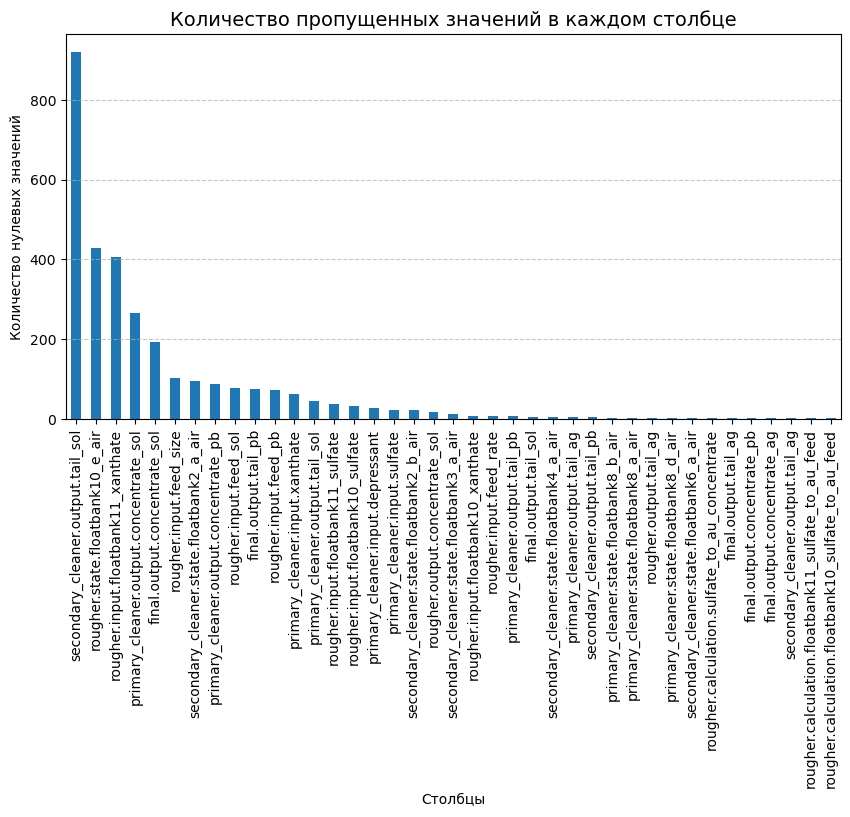

secondary_cleaner.output.tail_sol                     920
rougher.state.floatbank10_e_air                       429
rougher.input.floatbank11_xanthate                    407
primary_cleaner.output.concentrate_sol                265
final.output.concentrate_sol                          192
rougher.input.feed_size                               101
secondary_cleaner.state.floatbank2_a_air               94
primary_cleaner.output.concentrate_pb                  88
rougher.input.feed_sol                                 77
final.output.tail_pb                                   75
rougher.input.feed_pb                                  72
primary_cleaner.input.xanthate                         61
primary_cleaner.output.tail_sol                        45
rougher.input.floatbank11_sulfate                      36
rougher.input.floatbank10_sulfate                      31
primary_cleaner.input.depressant                       28
primary_cleaner.input.sulfate                          23
secondary_clea

In [10]:
#Запишем в переменную количество нулей в столбцах и оставим в ней только не те они есть
null_counts = df_gold_train.isnull().sum().sort_values(ascending=False)
null_counts = null_counts[null_counts > 0]
#Визуализируем ее
plt.figure(figsize=(10, 5))
null_counts.plot(kind='bar')
plt.title('Количество пропущенных значений в каждом столбце', fontsize=14)
plt.xlabel('Столбцы', fontsize=10)
plt.ylabel('Количество нулевых значений', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
#Выведем на экран текстовую версию
print(null_counts)

##### Выводы:
- Максимальное количество пропущенных значений имеет столбец secondary_cleaner.output.tail_sol - 920
- По гистограмме распределения после столбца 'secondary_cleaner.output.tail_sol' идут столбцы: rougher.state.floatbank10_e_air и rougher.input.floatbank11_xanthate со схожими значениями, далее количество пропусков в столбцах сильно и резко снижается
- Большинство столбцов имеют значения количества пропусков менее 100, что достаточно мало от общего объема информации данных, датасет имеет почти 15 000 строк
- Вероятнее всего, эти значения явлются выбросами или аномалиями, так-же их общее количество относительно всего датасета не велико - полагаю, что наиболее оптимальный вариант просто удалить строки в которых есть подобные значения из всех датасетов(хоть здесь мы рассмотрели один, а имеем три, они все предсталяют одно и тоже, за исключением некоторых столбцов)

#### 1.6.2 Удаление пропущенных значений:

In [28]:
#Удалим в датасете обучающей выборки
df_gold_train = df_gold_train.dropna()
#Удалим в датасете тестовой выборки
df_gold_test = df_gold_test.dropna()
#Удалим в датасете с общими данными
df_gold_full = df_gold_full.dropna()

#### Выводы:
- Мы провели успешную обработку данных удалив пропущенные значения
- Время приступать к следующим этапам

#### 1.6.3 Обработка значений ноль:

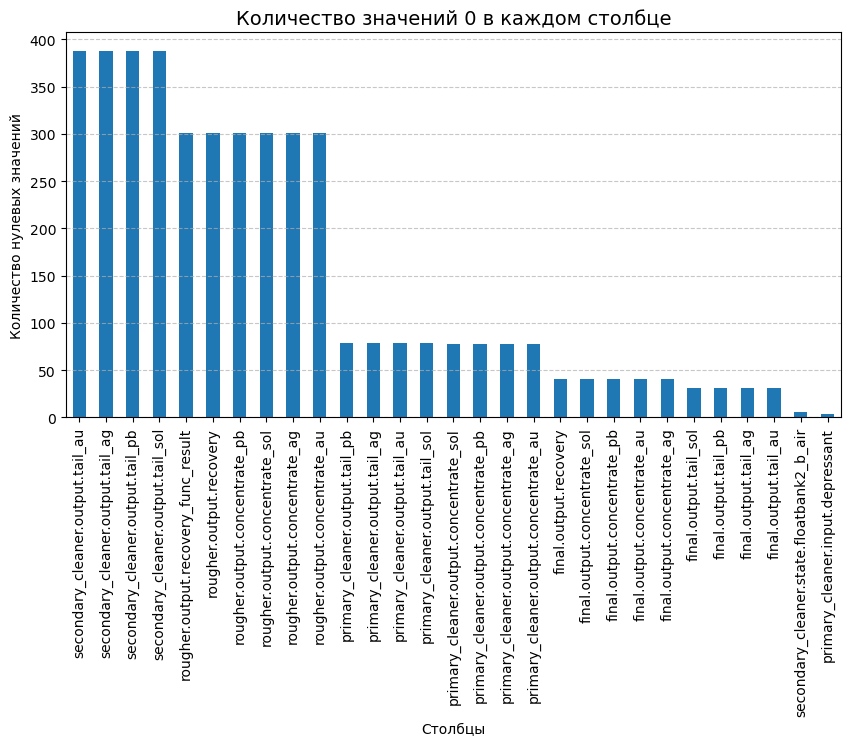

secondary_cleaner.output.tail_au            388
secondary_cleaner.output.tail_ag            388
secondary_cleaner.output.tail_pb            388
secondary_cleaner.output.tail_sol           388
rougher.output.recovery_func_result         301
rougher.output.recovery                     301
rougher.output.concentrate_pb               301
rougher.output.concentrate_sol              301
rougher.output.concentrate_ag               301
rougher.output.concentrate_au               301
primary_cleaner.output.tail_pb               79
primary_cleaner.output.tail_ag               79
primary_cleaner.output.tail_au               79
primary_cleaner.output.tail_sol              79
primary_cleaner.output.concentrate_sol       78
primary_cleaner.output.concentrate_pb        78
primary_cleaner.output.concentrate_ag        78
primary_cleaner.output.concentrate_au        78
final.output.recovery                        41
final.output.concentrate_sol                 41
final.output.concentrate_pb             

In [12]:
zero_counts = (df_gold_train == 0).sum().sort_values(ascending=False)
zero_counts = zero_counts[zero_counts > 0]
#Визуализируем ее
plt.figure(figsize=(10, 5))
zero_counts.plot(kind='bar')
plt.title('Количество значений 0 в каждом столбце', fontsize=14)
plt.xlabel('Столбцы', fontsize=10)
plt.ylabel('Количество нулевых значений', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
#Выведем на экран текстовую версию
print(zero_counts)

#### Выводы:
- Подобные значения есть в датафрейме - их необходимо обработать.
- Концентрация металлов в сырье == 0 в техпроцессе обработок встречать не может, значит нам необходимо избавиться от таких значений.

#### 1.6.4 Удаление пропущенных значений:

In [13]:
#Удалим в датасете обучающей выборки
df_gold_train = df_gold_train[df_gold_train != 0]
#Удалим в датасете тестовой выборки
df_gold_test = df_gold_test[df_gold_test != 0]
#Удалим в датасете с общими данными
df_gold_full = df_gold_full[df_gold_full != 0]

#### Выводы:
- Мы успешную обработали данные удалив значения ноль.

#### 1.6.5 Обработка значений 100% в коэффициентах восстановления золота:
- Коэффициент восстановления также не может равняться 100%, как 0, так как это означало бы, что всё золото, присутствующее в сырье, успешно передается в концентрат, что в реальных условиях недостижимо.
- Не будем тратить время не проверку, ведь в итоге нам все равно удалять эти значения, поэтому просто сразу избавимся от этих значений в датафреймах с обучающей выборкой и датасета с исходными данными, так как только в них есть значения коэффициентов впринципе.

In [14]:
#Избавимся от значений коэффицентов восстановления золота равным 100
#в датасете обучающей выборки
df_gold_train = df_gold_train[(df_gold_train['rougher.output.recovery'] != 0) | 
                              (df_gold_train['final.output.recovery'] != 0)]
#в датасете с общими данными
df_gold_full = df_gold_full[(df_gold_full['rougher.output.recovery'] != 0) | 
                            (df_gold_full['final.output.recovery'] != 0)]

## 2. Анализ данных

### 2.1 Оценим изменение концентрации металлов (Au, Ag, Pb) на различных этапах: в сырье, в черновом концентрате, в концентрате после первой очистки и в финальном концентрате. Оценим  особенности имеют распределения. Опишим выводы.
- Золото (Au): Ожидается увеличение концентрации золота от сырья до финального концентрата, так как основная цель процесса - извлечение золота. Большой разброс значений в сырье может быть связан с различными типами руды.
- Серебро (Ag) и свинец (Pb): Для серебра и свинца также ожидается увеличение концентрации на протяжении процесса, хотя это может быть менее выраженным, чем для золота. Важно также обратить внимание на наличие выбросов или аномалий в распределениях, которые могут указывать на проблемы или неравномерности в процессе обогащения.

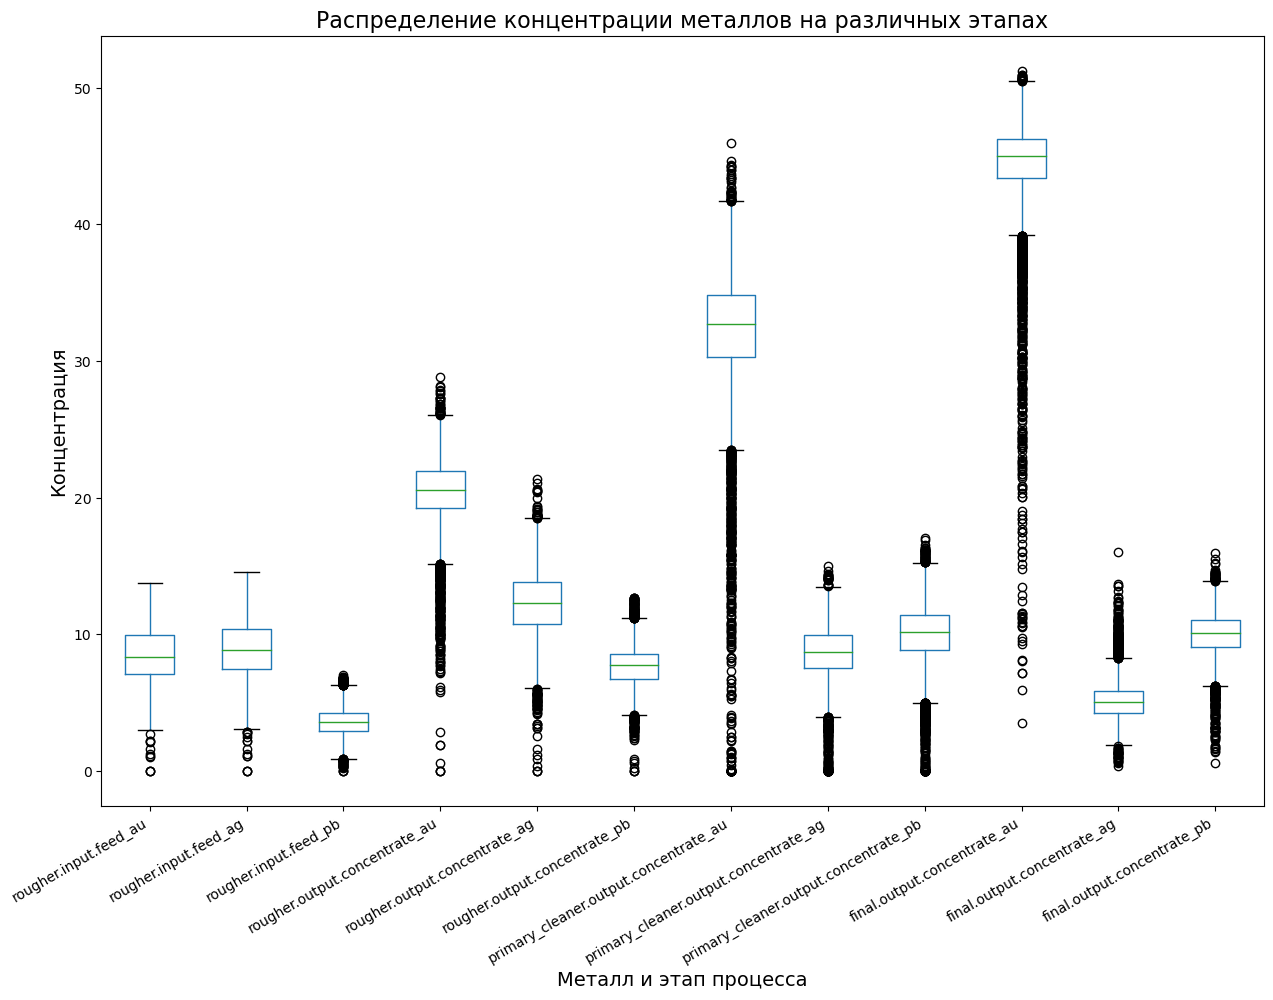

In [15]:
#Выберем столбцы с концентрацией золота (Au), серебра (Ag) и свинца (Pb)
metals = ['au', 
          'ag', 
          'pb']
#Запишем стадии обработки
stages = ['rougher.input.feed', 
          'rougher.output.concentrate', 
          'primary_cleaner.output.concentrate', 
          'final.output.concentrate']
#Создадим пустой DataFrame для хранения данных о концентрации металлов на различных этапах
metal_concentrations = pd.DataFrame()

#Соберем данные о концентрации металлов на различных этапах в один DataFrame
for stage in stages:
    for metal in metals:
        column_name = f"{stage}_{metal}"
        metal_concentrations[column_name] = df_gold_train[f"{stage}_{metal}"]

#Построим ящик с усами для каждого металла на различных этапах
plt.figure(figsize=(15, 10))
metal_concentrations.boxplot(column=list(metal_concentrations.columns), grid=False)
plt.title('Распределение концентрации металлов на различных этапах', fontsize=16)
plt.xlabel('Металл и этап процесса', fontsize=14)
plt.ylabel('Концентрация', fontsize=14)
plt.xticks(rotation=30, ha='right')  #поворот названий столбцов для лучшей читаемости
plt.show()

#### Выводы:
- Золото (Au):
  - Медиана концентрации золота увеличивается по мере прохождения этапов обработки
  - Вместе с ней увеличивается диапазон(разница между наибольшим и наименьшим значениями), количество потенциальных  выбросов
  - А вот разброс остается таким-же
- Серебро (Ag) и свинец (Pb): 
  - Для серебра и свинца ситуация примерно такая-же как с золотом только вот для этапов сырья и чернового концентрата, далее, на этапе первой очистки, происходит общее снижение их концентрации и всех ее распределений: медианы, диапазона, разброса.
  - Их меньшая концентрация достигается на этапе финального концентрата, что впринципе логично, ведь мы пытаемся в итоге получить золото, соответственно другие руды отсеиваются

### 2.2 Сравним распределения размеров гранул исходного сырья на обучающей и тестовой выборках. 
- Если распределения сильно отличаются друг от друга, оценка модели будет неправильной.

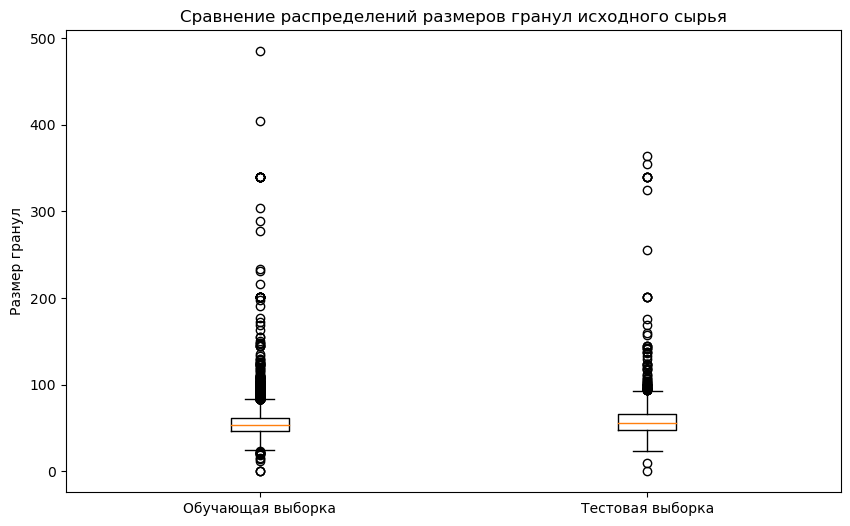

In [16]:
#Создаем фигуру
plt.figure(figsize=(10, 6))
#Построим ящик с усами для обучающей и тестовой выборок
plt.boxplot([df_gold_train['rougher.input.feed_size'], 
             df_gold_test['rougher.input.feed_size']], 
             labels=['Обучающая выборка', 'Тестовая выборка'])
#Добавим заголовки и метки осей
plt.title('Сравнение распределений размеров гранул исходного сырья')
plt.ylabel('Размер гранул')
#Отобразим график
plt.show()

##### Вывод:
- Распределение двух выборок очень схожи, практически идентично, значит можем смело строить модель

### 2.3 Исследуем суммарную концентрацию металлов на разных стадиях: в сырье, в черновом концентрате, в концентрате после первой очистки и в финальном концентрате.

In [17]:
#Создадим пустой датафрейм 
temp = pd.DataFrame()
#Рассчитаем суммарную концентрацию металлов на каждом этапе и запишем в temp
#в сырье
temp['sum_feed'] = (df_gold_train['rougher.input.feed_au'] + 
                    df_gold_train['rougher.input.feed_ag'] + 
                    df_gold_train['rougher.input.feed_pb'])
#после флотации
temp['sum_rougher_output'] = (df_gold_train['rougher.output.concentrate_au'] + 
                              df_gold_train['rougher.output.concentrate_ag'] + 
                              df_gold_train['rougher.output.concentrate_pb'])
#после первичной очистки
temp['sum_primary_cleaner_output'] = (df_gold_train['primary_cleaner.output.concentrate_au'] + 
                                      df_gold_train['primary_cleaner.output.concentrate_ag'] + 
                                      df_gold_train['primary_cleaner.output.concentrate_pb'])
#в финальном концентрате
temp['sum_final_output'] = (df_gold_train['final.output.concentrate_au'] + 
                            df_gold_train['final.output.concentrate_ag'] + 
                            df_gold_train['final.output.concentrate_pb'])

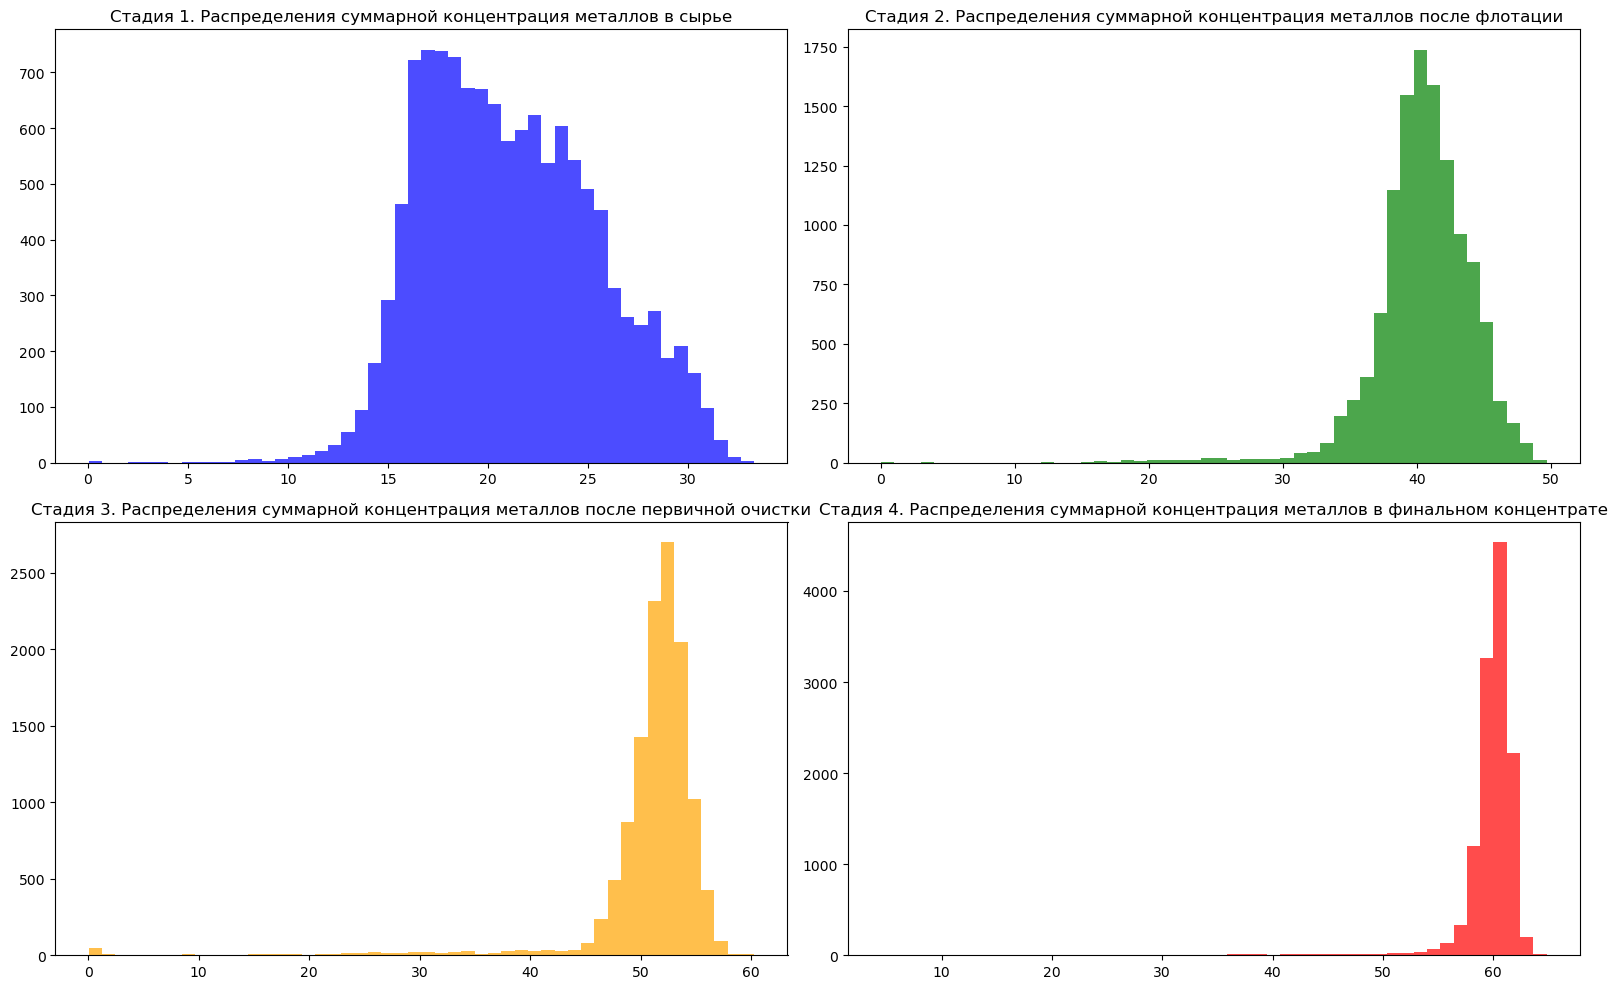

In [18]:
#Построение гистограмм распределения для суммарной концентрации металлов на каждой стадии
plt.figure(figsize=(16, 10))

plt.subplot(2, 2, 1)
plt.hist(temp['sum_feed'], 
         bins=50, 
         color='blue', 
         alpha=0.7)
plt.title('Стадия 1. Распределения суммарной концентрация металлов в сырье', fontsize=12)

plt.subplot(2, 2, 2)
plt.hist(temp['sum_rougher_output'], 
         bins=50, 
         color='green', 
         alpha=0.7)
plt.title('Стадия 2. Распределения суммарной концентрация металлов после флотации', fontsize=12)

plt.subplot(2, 2, 3)
plt.hist(temp['sum_primary_cleaner_output'], 
         bins=50,
         color='orange', 
         alpha=0.7)
plt.title('Стадия 3. Распределения суммарной концентрация металлов после первичной очистки', fontsize=12)

plt.subplot(2, 2, 4)
plt.hist(temp['sum_final_output'], 
         bins=50, 
         color='red', 
         alpha=0.7)
plt.title('Стадия 4. Распределения суммарной концентрация металлов в финальном концентрате', fontsize=12)

plt.tight_layout()
plt.show()

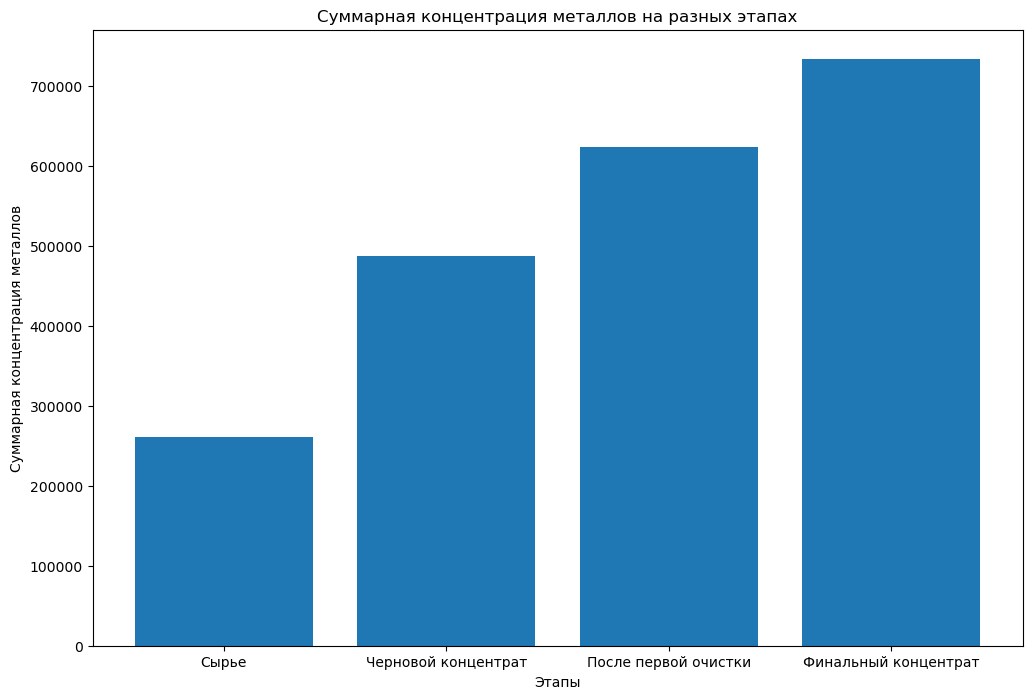

In [19]:
#Построим гистрограмму для каждого этапа
plt.figure(figsize=(12, 8))
plt.bar(
['Сырье', 'Черновой концентрат', 'После первой очистки', 'Финальный концентрат'], #названия столбцов
(temp['sum_feed'].sum(),temp['sum_rougher_output'].sum(),temp['sum_primary_cleaner_output'].sum(),temp['sum_final_output'].sum())#значения столбцов
        )
#Легента, название осей
plt.title('Суммарная концентрация металлов на разных этапах')
plt.xlabel('Этапы')
plt.ylabel('Суммарная концентрация металлов')
#Вывод
plt.show()

##### Вывод:
- Есть стойкий тренд увеличения суммарной концентрации металлов по мере прохождения руды по этапам обработки
- Наибольший скачок происходит с этапа сырья к этапу чернового концентрата
- Затем увеличения концентрация примерно одинаковое для каждого этапа

## 3. Модель

### 3.1 Напишем функцию для вычисления итоговой sMAPE.
- Для вычисления итоговой симметричной средней абсолютной процентной ошибки (sMAPE) нам нужно сначала реализовать функцию для вычисления sMAPE для одного прогноза. Затем использовать эту функцию для вычисления sMAPE для двух различных типов данных и, наконец, объединить результаты для получения итоговой sMAPE.

In [20]:
#Функция вычисления sMAPE для одного прогноза. 
def smape(target, predict):
    denominator = (np.abs(target) + np.abs(predict)) / 2.0
    #Добавление небольшой константы epsilon к знаменателю, чтобы избежать деления на ноль
    epsilon = 1e-8
    diff = np.abs(target - predict) / (denominator + epsilon)
    diff = np.nan_to_num(diff, nan=0.0)
    return 100 * np.mean(diff)

In [ ]:
#Функцию вычисления итогового sMAPE
def total_smape(target_rougher, target_final, predict_rougher, predict_final):
    rougher_weight=0.25
    #Используем функцию вычисления sMAPE для одного прогноза поочереди для:
    #эффективности обогащения чернового концентрата 
    smape_rougher = smape(target_rougher, predict_rougher)
    #эффективности обогащения финального концентрата 
    smape_final = smape(target_final, predict_final)
    #Считаем итоговый sMAPE
    total_smape = (rougher_weight * smape_rougher) + ((1 - rougher_weight) * smape_final)
    #Возвращаем результат работы - итоговый sMAPE
    return total_smape

In [21]:
#Функция вычисления итогового sMAPE
def total_smape(target, predict):
    #Преобразование DataFrame в numpy arrays, если это необходимо
    if isinstance(target, pd.DataFrame):
        target = target.to_numpy()
    if isinstance(predict, pd.DataFrame):
        predict = predict.to_numpy()

    smape_rougher = smape(target[:, 0], predict[:, 0]) 
    smape_final = smape(target[:, 1], predict[:, 1])
    total_smape = 0.25 * smape_rougher + 0.75 * smape_final
    
    return total_smape

### 3.2. Обучим разные модели и оценим их качество кросс-валидацией. Выберим лучшую модель и проверим её на тестовой выборке. Опишим выводы.

#### 3.2.1 Напишем универсальную функцию оценки моделей с помощью GridSearch

In [22]:
#Функция будет иметь на вход три аргумента: данные, модель для использования, параметры модели
def best_params_model(data, model, param_grid): 
    #Разобъем признаки
    features = data[df_gold_test.columns].drop(['date'], axis=1)
    target = data[['rougher.output.recovery', 'final.output.recovery']]
    
    #Создаем метрику smape_scorer
    smape_scorer = make_scorer(total_smape, greater_is_better=False)

    #Создадим экземпляр GridSearchCV
    grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring=smape_scorer)
    #Оптимизируем модель
    grid_search.fit(features, target)
    
    #Получение лучшей модели
    best_model = grid_search.best_estimator_
    #Получение наилучших параметров
    best_params = grid_search.best_params_
    #Получение значения метрики sMAPE для лучшей модели
    best_smape = -grid_search.best_score_

    return best_params, best_smape

#### 3.2.2 Запишем в переменные модели и сетки параметров для применение в качестве аргументов функции

#### 3.2.3 Применим функцию с разными моделями

In [29]:
#Запишем результат работы функции для разных моделей в соответствующие переменные
result_model_1 = best_params_model(df_gold_train, model_1, param_grid_1)
result_model_2 = best_params_model(df_gold_train, model_2, param_grid_2)
result_model_3 = best_params_model(df_gold_train, model_3, param_grid_3)

#### 3.2.4 Поочередно вытащим из переменных с результатами работы модели параметры и оценим результат работы каждой модели. Сделаем выводы.

In [30]:
#Вытащим и запишим в переменные выводимые функцией значения для модели №1
best_params_model_1 = result_model_1[0]
best_smape_model_1 = result_model_1[1]
print('Лучшие гиперпараметры для модели RandomForestRegressor:')
print(best_params_model_1)
print('Итоговое sMAPE модели при таких параметрах:')
print(best_smape_model_1)

Лучшие гиперпараметры для модели RandomForestRegressor:
{'max_depth': 1, 'n_estimators': 4}
Итоговое sMAPE модели при таких параметрах:
7.727376167677917


In [31]:
#Вытащим и запишим в переменные выводимые функцией значения для модели №2
best_params_model_2 = result_model_2[0]
best_smape_model_2 = result_model_2[1]
print('Лучшие гиперпараметры для модели LinearRegression:')
print(best_params_model_2)
print('Итоговое sMAPE модели при таких параметрах:')
print(best_smape_model_2)

Лучшие гиперпараметры для модели LinearRegression:
{}
Итоговое sMAPE модели при таких параметрах:
8.665548400607682


In [32]:
#Вытащим и запишим в переменные выводимые функцией значения для модели №3
best_params_model_3 = result_model_3[0]
best_smape_model_3 = result_model_3[1]
print('Лучшие гиперпараметры для модели DecisionTreeRegressor:')
print(best_params_model_3)
print('Итоговое sMAPE модели при таких параметрах:')
print(best_smape_model_3)

Лучшие гиперпараметры для модели DecisionTreeRegressor:
{'max_depth': 1}
Итоговое sMAPE модели при таких параметрах:
7.751190274180141


##### Выводы:
- Наилучшее(оно же наименьшее) значение sMAPE у модели RandomForestRegressor при гиперпараметрах:
  - 'max_depth': 3, 
  - 'n_estimators': 2
- Значение sMAPE в 9.65 означает, что в среднем прогнозы отклоняются от фактических значений на примерно  9.6%. Это является довольно хорошим показателем и говорит о том, что модель весьма точно предсказывает целевые признаки.

### 3.3 Проверим лучшую модель на тестовой выборке.

In [33]:
#Сначала получим таргеты из df_gold_full и вставим их в тестовую выборку
df_gold_test = pd.merge(df_gold_test, 
                        df_gold_full[['date', 'rougher.output.recovery', 'final.output.recovery']], 
                        on='date', 
                        how='left')
#Разобьем признаки
#тестовые
features_test = df_gold_test.drop(['date', 'rougher.output.recovery', 'final.output.recovery'], axis=1)
target_test = df_gold_test[['rougher.output.recovery', 'final.output.recovery']]
#обучающие
features_train = df_gold_train[features_test.columns]
target_train = df_gold_train[['rougher.output.recovery', 'final.output.recovery']]
#Создадим модель
model = RandomForestRegressor(max_depth=3, n_estimators=2, random_state=state)
#Обучим ее 
model.fit(features_train, target_train)
#Получим предсказания
predictions = model.predict(features_test)
#Посмотрим метрику итогового sMAPE
print('Итоговое sMAPE модели RandomForestRegressor при гиперпараметрах - max_depth: 3, n_estimators: 2; на тестовой выборке:')
print(total_smape(target_test, predictions))

Итоговое sMAPE модели RandomForestRegressor при гиперпараметрах - max_depth: 3, n_estimators: 2; на тестовой выборке:
5.008266932397829


#### Выводы:
- Итоговое sMAPE выбранной модели: RandomForestRegressor при гиперпараметрах - max_depth: 3, n_estimators: 2; весьма удовлетворительно
- Модель прошла проверку

## Итоговый вывод:
#### Цель проекта заключалась в построении модели для предсказания коэффициента восстановления золота из золотосодержащей руды.

- В ходе исследования были выполнены следующие шаги:

  - Загрузка и подготовка данных:
    - Импортировали необходимые библиотеки и модули.
    - Прочитали файлы и сохранили данные в переменные.
      - Оценили содержимое датасетов и описали его.
          - Проверили правильность расчета эффективности обогащения для признака rougher.output.recovery и вычислили её на обучающей выборке.
      - Проанализировали признаки, недоступные в тестовой выборке, и определили их тип.
  - Анализ данных:
      - Оценили изменение концентрации металлов (Au, Ag, Pb) на различных этапах обработки.
      - Сравнили распределения размеров гранул исходного сырья на обучающей и тестовой выборках.
      - Исследовали суммарную концентрацию металлов на разных стадиях обработки.
   - Построение модели:
      - Написали функцию для вычисления итоговой sMAPE.
      - Обучили разные модели и оценили их качество кросс-валидацией.
      - Выбрали лучшую модель и проверили её на тестовой выборке.
      - Проверка лучшей модели на тестовой выборке:
      - Получили предсказания модели на тестовой выборке.

#### Итоговое значение sMAPE лучшей модели RandomForestRegressor при гиперпараметрах max_depth: 3, n_estimators: 2 на тестовой выборке составило 5.67.
#### Данное значение sMAPE указывает на то, что прогнозы модели отклоняются от фактических значений примерно на 5.67%, что говорит о достаточно высокой точности модели.
#### Таким образом, модель RandomForestRegressor с подобранными гиперпараметрами показала хорошие результаты в предсказании коэффициента восстановления золота из золотосодержащей руды.